# Acoustic Feature Analysis

## AI Tool for Early Stage Dementia Detection

This notebook performs acoustic analysis of the speech dataset used in the project.

### Objectives
- Explore the speech dataset
- Analyze audio duration
- Extract acoustic features
- Compare acoustic characteristics between classes
- Check data quality
- Visualize waveform and spectrogram
- Prepare an acoustic feature dataset for further ML analysis


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATASET_PATH = "../dataset"

print("Dataset path:", os.path.abspath(DATASET_PATH))

Dataset path: D:\SKIT_Project\dataset


In [3]:
classes = ["dementia", "nodementia"]

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    print(f"\nClass: {cls}")
    print("Exists:", os.path.exists(class_path))

    if os.path.exists(class_path):
        print("Number of speaker folders:",
              len([
                  x for x in os.listdir(class_path)
                  if os.path.isdir(os.path.join(class_path, x))
              ]))


Class: dementia
Exists: True
Number of speaker folders: 85

Class: nodementia
Exists: True
Number of speaker folders: 106


In [4]:
audio_records = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(".wav"):
                audio_records.append({
                    "file": file,
                    "class": cls,
                    "filepath": os.path.join(root, file)
                })

audio_df = pd.DataFrame(audio_records)

print("Total audio files:", len(audio_df))
print("\nClass distribution:")
print(audio_df["class"].value_counts())

audio_df.head()

Total audio files: 360

Class distribution:
class
nodementia    229
dementia      131
Name: count, dtype: int64


,file,class,filepath
0,AbeBurrows_5.wav,dementia,../dataset\dementia\Abe Burrows\AbeBurrows_5.wav
1,aileenhernandez_0.wav,dementia,../dataset\dementia\Aileen Hernandez\aileenher...
2,aileenhernandez_5_1.wav,dementia,../dataset\dementia\Aileen Hernandez\aileenher...
3,aileenhernandez_5_2.wav,dementia,../dataset\dementia\Aileen Hernandez\aileenher...
4,alanramsey_10.wav,dementia,../dataset\dementia\Alan Ramsey\alanramsey_10.wav


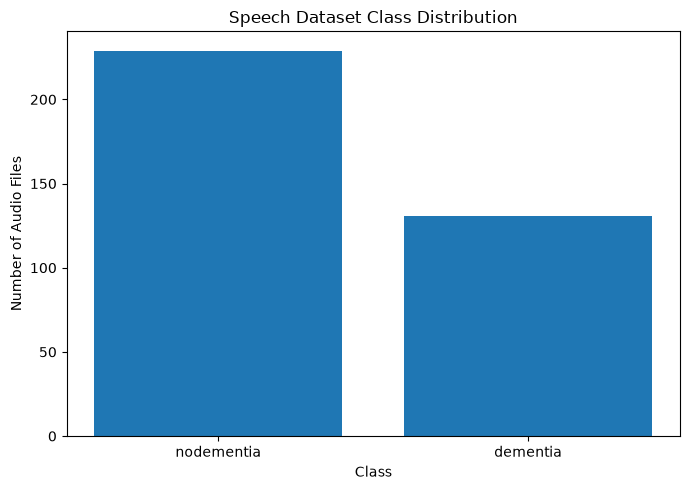

In [5]:
class_counts = audio_df["class"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("Speech Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Audio Files")

plt.tight_layout()
plt.show()

In [6]:
duration_records = []

for _, row in audio_df.iterrows():
    try:
        duration = librosa.get_duration(path=row["filepath"])

        duration_records.append({
            "file": row["file"],
            "class": row["class"],
            "duration_seconds": duration
        })

    except Exception as e:
        print("Error:", row["filepath"], e)

duration_df = pd.DataFrame(duration_records)

print("Total files analyzed:", len(duration_df))
duration_df.groupby("class")["duration_seconds"].describe()

Total files analyzed: 360


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
dementia,131.0,55.941386,29.878599,8.5,33.005533,49.01034,90.0,162.003719
nodementia,229.0,52.750218,26.711532,6.0,29.000000,48.00000,81.0,90.100000


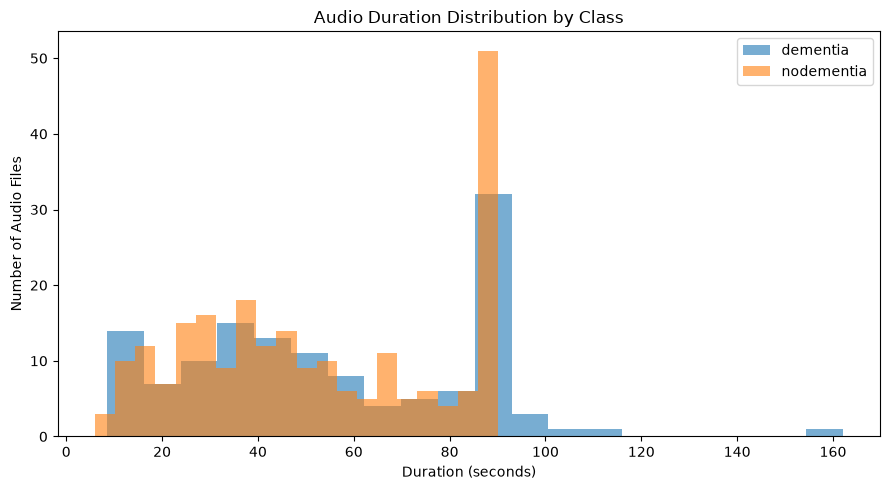

In [7]:
plt.figure(figsize=(9, 5))

for cls in classes:
    values = duration_df[
        duration_df["class"] == cls
    ]["duration_seconds"]

    plt.hist(
        values,
        bins=20,
        alpha=0.6,
        label=cls
    )

plt.title("Audio Duration Distribution by Class")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Audio Files")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
def extract_acoustic_features(filepath):

    y, sr = librosa.load(filepath, sr=None)

    rms = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)

    spectral_centroid = librosa.feature.spectral_centroid(
        y=y, sr=sr
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y, sr=sr
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y, sr=sr
    )

    return {
        "duration": librosa.get_duration(y=y, sr=sr),
        "sample_rate": sr,
        "rms_mean": np.mean(rms),
        "zcr_mean": np.mean(zcr),
        "spectral_centroid_mean": np.mean(spectral_centroid),
        "spectral_bandwidth_mean": np.mean(spectral_bandwidth),
        "spectral_rolloff_mean": np.mean(spectral_rolloff)
    }

In [9]:
acoustic_records = []

for _, row in audio_df.iterrows():

    try:
        features = extract_acoustic_features(row["filepath"])

        features["file"] = row["file"]
        features["class"] = row["class"]

        acoustic_records.append(features)

    except Exception as e:
        print("Error:", row["filepath"], e)

acoustic_df = pd.DataFrame(acoustic_records)

print("Acoustic feature dataset shape:", acoustic_df.shape)
acoustic_df.head()

Acoustic feature dataset shape: (360, 9)


,duration,sample_rate,rms_mean,zcr_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,file,class
0,71.019683,44100,0.039122,0.053061,2407.677048,3070.416454,4908.546095,AbeBurrows_5.wav,dementia
1,47.000000,44100,0.034694,0.055883,2246.970803,2811.005358,4230.968620,aileenhernandez_0.wav,dementia
2,38.000000,44100,0.071403,0.089645,3275.831738,3291.119055,6205.015442,aileenhernandez_5_1.wav,dementia
3,90.000000,44100,0.029308,0.074341,3046.372016,3604.375093,6103.921424,aileenhernandez_5_2.wav,dementia
4,55.000000,44100,0.016954,0.049693,1698.381181,1827.806508,3215.032663,alanramsey_10.wav,dementia


In [10]:
numeric_features = [
    "duration",
    "rms_mean",
    "zcr_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean"
]

print("Overall feature statistics:")
display(acoustic_df[numeric_features].describe())

print("\nClass-wise mean:")
display(
    acoustic_df.groupby("class")[numeric_features].mean()
)

Overall feature statistics:


,duration,rms_mean,zcr_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,53.911448,0.039801,0.057826,2247.063628,2695.693205,4370.107368
std,27.906676,0.034307,0.028766,699.109397,588.779714,1500.430240
min,6.000000,0.000099,0.006589,723.930157,1362.768764,1124.137647
25%,30.974994,0.019497,0.042401,1783.966815,2296.218842,3337.468352
50%,48.014558,0.029727,0.052474,2173.626593,2632.623568,4179.195752
75%,85.000000,0.045197,0.067333,2586.148032,3075.159364,5232.468518
max,162.003719,0.233439,0.337615,7676.434296,5150.005631,12978.745575



Class-wise mean:


,duration,rms_mean,zcr_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean
class,,,,,,
dementia,55.941386,0.043855,0.054758,2192.339338,2640.363719,4268.993002
nodementia,52.750218,0.037482,0.059581,2278.368790,2727.344571,4427.950084


In [11]:
quality_report = pd.DataFrame({
    "Missing Values": acoustic_df.isnull().sum(),
    "Missing Percentage": (
        acoustic_df.isnull().mean() * 100
    ).round(2)
})

display(quality_report)

print(
    "Duplicate rows:",
    acoustic_df.duplicated().sum()
)

,Missing Values,Missing Percentage
duration,0,0.0
sample_rate,0,0.0
rms_mean,0,0.0
zcr_mean,0,0.0
spectral_centroid_mean,0,0.0
spectral_bandwidth_mean,0,0.0
spectral_rolloff_mean,0,0.0
file,0,0.0
class,0,0.0


Duplicate rows: 0


<Figure size 800x500 with 0 Axes>

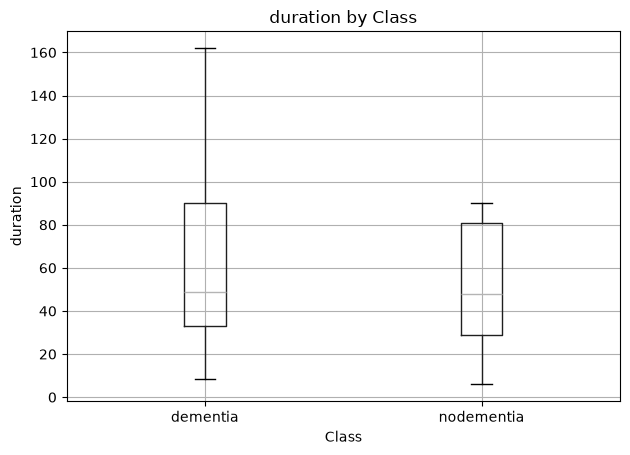

<Figure size 800x500 with 0 Axes>

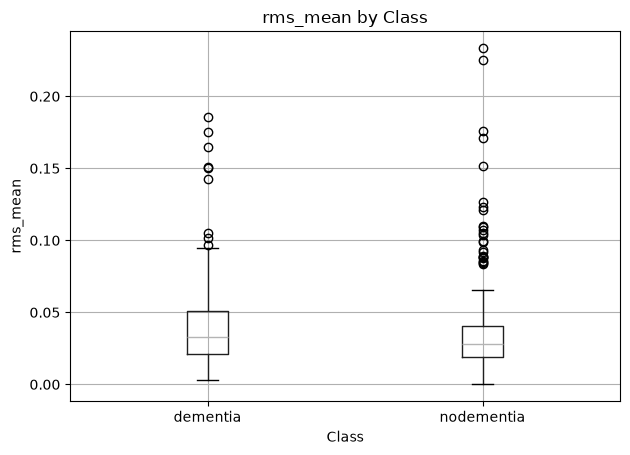

<Figure size 800x500 with 0 Axes>

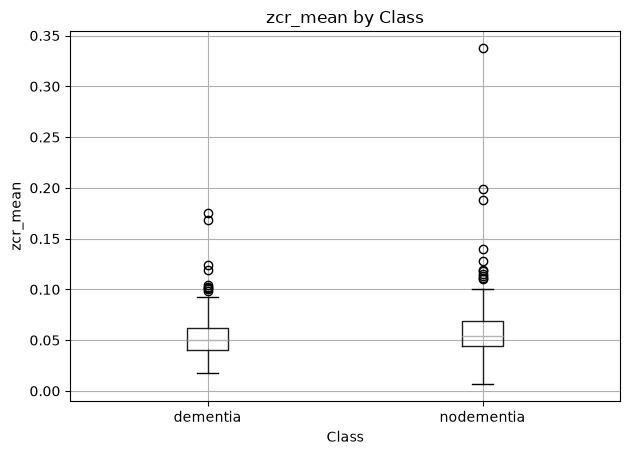

<Figure size 800x500 with 0 Axes>

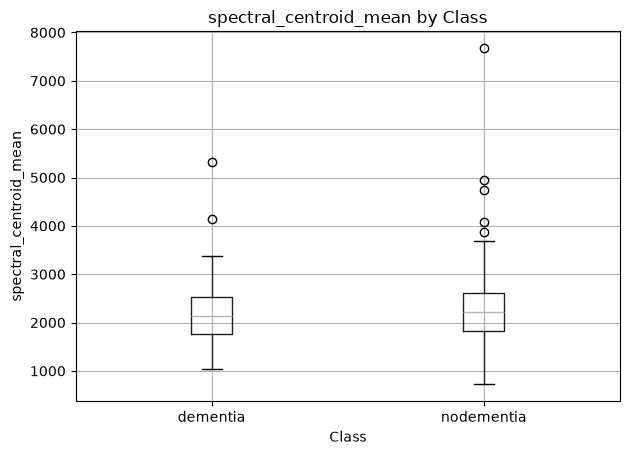

<Figure size 800x500 with 0 Axes>

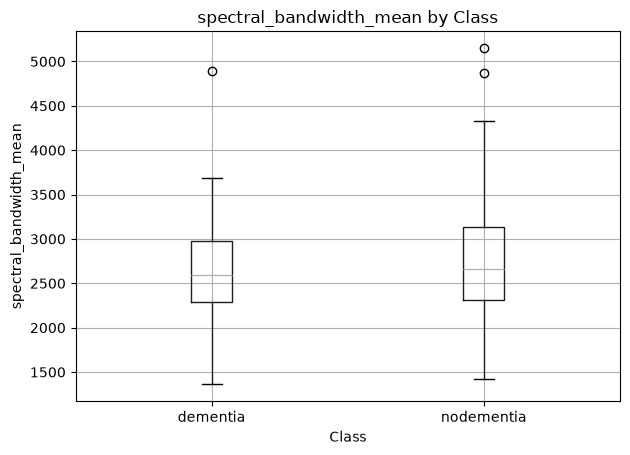

<Figure size 800x500 with 0 Axes>

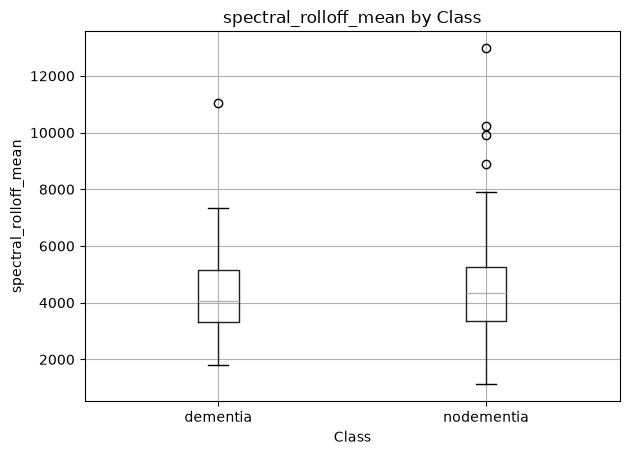

In [12]:
for feature in numeric_features:

    plt.figure(figsize=(8, 5))

    acoustic_df.boxplot(
        column=feature,
        by="class"
    )

    plt.title(f"{feature} by Class")
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

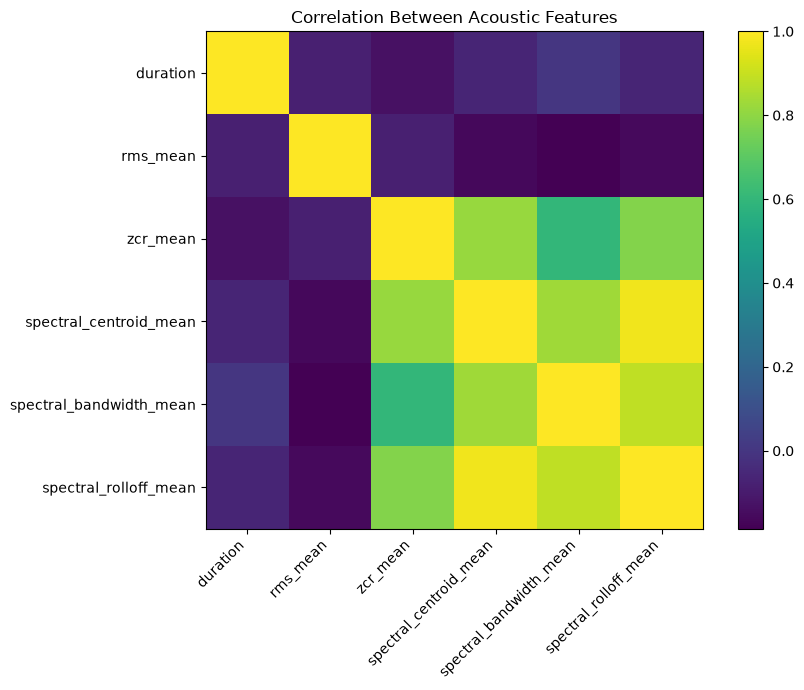

In [13]:
correlation = acoustic_df[numeric_features].corr()

plt.figure(figsize=(9, 7))

plt.imshow(correlation)

plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_features)),
    numeric_features
)

plt.colorbar()

plt.title("Correlation Between Acoustic Features")

plt.tight_layout()
plt.show()

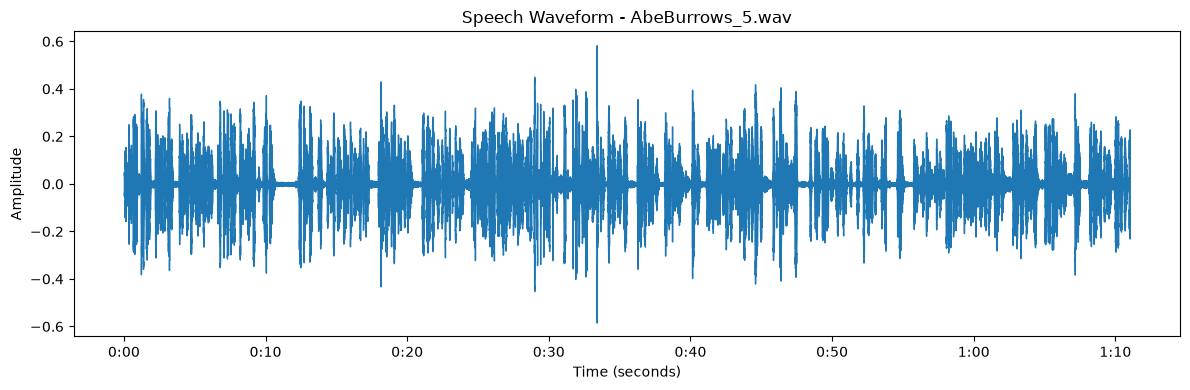

In [14]:
sample = audio_df.iloc[0]

y, sr = librosa.load(
    sample["filepath"],
    sr=None
)

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title(
    f"Speech Waveform - {sample['file']}"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

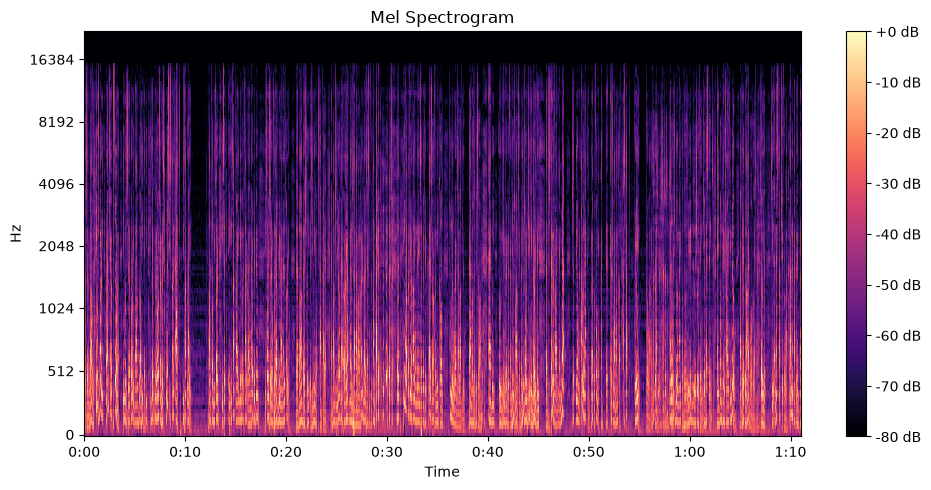

In [15]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(10, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Mel Spectrogram")

plt.tight_layout()
plt.show()

In [16]:
output_dir = "../analysis_output"

os.makedirs(output_dir, exist_ok=True)

acoustic_df.to_csv(
    os.path.join(output_dir, "acoustic_features.csv"),
    index=False
)

duration_df.to_csv(
    os.path.join(output_dir, "audio_duration_analysis.csv"),
    index=False
)

print("Analysis completed successfully.")
print("Files saved in:", os.path.abspath(output_dir))

Analysis completed successfully.
Files saved in: D:\SKIT_Project\analysis_output


In [17]:
print("=" * 50)
print("FINAL DATASET ANALYSIS SUMMARY")
print("=" * 50)

print("Total audio files:", len(audio_df))
print(
    "Dementia files:",
    (audio_df["class"] == "dementia").sum()
)
print(
    "Non-dementia files:",
    (audio_df["class"] == "nodementia").sum()
)
print("Acoustic features:", len(numeric_features))
print(
    "Average duration:",
    round(acoustic_df["duration"].mean(), 2),
    "seconds"
)
print(
    "Duplicate rows:",
    acoustic_df.duplicated().sum()
)

print("\nAnalysis pipeline completed.")

FINAL DATASET ANALYSIS SUMMARY
Total audio files: 360
Dementia files: 131
Non-dementia files: 229
Acoustic features: 6
Average duration: 53.91 seconds
Duplicate rows: 0

Analysis pipeline completed.
